# Fig 3: behavioral context (Passive / Repeat / Decision)

Linear: **SHI-57**. Paper title: *Insula response depends differently on behavioral context*.

Separate SVGs (assemble in Adobe):

1. **Waveforms** — cluster rows × stimulus / delay / response; hue = Passive / Repeat / Decision
1b. **Difference waveforms** — same grid; Repeat − Passive (PictureNaming) and Decision − Repeat (LexicalDelay), electrode-paired within task
1c. **Difference waveforms by contrast** — four rows (PN / LND Repeat − Passive, LD / LND Decision − Repeat); hue = sensory / sustain / motor
2. **Spatial** — LexicalDelay Delay window, Decision > Repeat, NMF cluster colors
3. **Paired points** — 2 × 3 Delay P75: Repeat vs Passive (top) and Decision vs Repeat (bottom)

Same electrodes in every waveform condition: per-subject significance union ∩ NMF
assignments. Waveforms are trial-averaged `epoch(band)(zscore)` high-gamma
(not packaged `results/hga/` CSVs). PictureNaming is sound only. SentenceRep
is excluded.

Run the load and spatial cells on a compute node (spatial needs GL).
Style: [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md). SVG only.


In [1]:
%matplotlib inline

import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex, to_rgb
from mne_bids import BIDSPath
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.connectivity.pairwise.config import DEFAULT_DATASETS
from src.nmf.waveform_analysis import CLUSTER_LABELS, FUNCTION_COLORS
from src.paths import img_dir, nmf_assignments_path, save_svg

In [2]:
from matplotlib import font_manager

for _ttf in (Path(sys.prefix) / "fonts").glob("arial*.ttf"):
    font_manager.fontManager.addfont(str(_ttf))

cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

fontsize = 7
fontdict = dict(fontsize=fontsize)

CLUSTERS = ["sensory", "sustain", "motor"]

TASKS = [
    "LexicalDelay",
    "LexicalNoDelay",
    "PictureNaming",
    "PhonemeSequence",
]
TASK_BIDS = {
    task: str(root)
    for task, root in DEFAULT_DATASETS.items()
    if task in TASKS
}
DESCRIPTIONS = ["Passive", "Repeat", "Decision"]

CONDITION_TASKS = {
    "Passive": ["LexicalNoDelay", "PictureNaming"],
    "Repeat": ["LexicalDelay", "LexicalNoDelay", "PictureNaming", "PhonemeSequence"],
    "Decision": ["LexicalDelay", "LexicalNoDelay"],
}

REF = "bipolar"
BAND = "highgamma"
MODALITY = "sound"
HEMI = None
EXCLUDE_SUBJECTS = {"D0121"}
TIME_MAX = 1.5

# Outlier Passive-response electrodes (large peak / temporal variance).
DROP_CHANNELS = {
    "D0125_LTMS3-4",
    "D0125_LTMS2-3",
    "D0125_LTMS1-2",
    "D0129_LFAI2-3",
}

NMF_ASSIGNMENTS = nmf_assignments_path()
IMG_DIR = img_dir("fig3")

## Helpers

- Per subject: union of significant channels across conditions × phases
- Intersect with NMF assignments so the same electrodes enter every curve
- Trial-average `epoch(band)(zscore)` after `.pick`


In [3]:
def _norm_phase(phase: str) -> str:
    p = str(phase)
    if p == "Resp":
        p = "Response"
    elif p == "Audio":
        p = "Stimulus"
    return p.lower()


def _norm_subject(subject: str) -> str:
    return subject.removeprefix("sub-")


def _modality_of(path) -> str:
    return path.recording if path.recording is not None else "sound"


def epoch_root(bids_root: str) -> str:
    return str(Path(bids_root) / f"derivatives/epoch({REF})")


def load_assignments(path: Path | None = None) -> pd.DataFrame:
    path = Path(path) if path is not None else NMF_ASSIGNMENTS
    meta = pd.read_csv(path)
    required = {"subject", "channel", "functional_cluster"}
    missing = required - set(meta.columns)
    if missing:
        raise ValueError(f"{path} missing columns: {sorted(missing)}")
    meta = meta.copy()
    meta["subject"] = meta["subject"].map(_norm_subject)
    meta = meta[meta["functional_cluster"].isin(CLUSTERS)].copy()
    if HEMI is not None and "hemi" in meta.columns:
        meta = meta[meta["hemi"] == HEMI]
    meta = meta[~meta["subject"].isin(EXCLUDE_SUBJECTS)]
    meta = meta.drop_duplicates(subset=["subject", "channel"], keep="first")
    return meta.reset_index(drop=True)


def list_sig_paths(bids_root: str):
    return BIDSPath(
        root=epoch_root(bids_root),
        datatype="epoch(band)(sig)",
        suffix=BAND,
        extension=".h5",
        check=False,
    ).match()


def list_zscore_paths(bids_root: str):
    return BIDSPath(
        root=epoch_root(bids_root),
        datatype="epoch(band)(zscore)",
        suffix=BAND,
        extension=".h5",
        check=False,
    ).match()


def sig_union_by_subject(sig_paths, descriptions=DESCRIPTIONS) -> dict[str, set[str]]:
    by_subj: dict[str, set[str]] = defaultdict(set)
    for path in tqdm(sig_paths, desc="sig union"):
        if path.description not in descriptions:
            continue
        if _modality_of(path) != MODALITY:
            continue
        subj = _norm_subject(path.subject)
        if subj in EXCLUDE_SUBJECTS:
            continue
        epochs = mne.read_epochs(path, preload=False, verbose=False)
        by_subj[subj].update(epochs.ch_names)
    return dict(by_subj)


def evoked_to_long(epochs, channels: list[str]) -> pd.DataFrame | None:
    picks = [ch for ch in channels if ch in epochs.ch_names]
    if not picks:
        return None
    epo = epochs.copy().pick(picks)
    data = np.nanmean(epo.get_data(copy=False), axis=0)
    times = epo.times
    n_ch, n_t = data.shape
    return pd.DataFrame(
        {
            "time": np.tile(times, n_ch),
            "channel": np.repeat(list(epo.ch_names), n_t),
            "value": data.reshape(-1),
        }
    )


def load_task_waveforms(
    task: str,
    assignments: pd.DataFrame,
    *,
    descriptions=DESCRIPTIONS,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    bids_root = TASK_BIDS[task]
    sig_paths = list_sig_paths(bids_root)
    z_paths = list_zscore_paths(bids_root)
    if not sig_paths or not z_paths:
        raise FileNotFoundError(f"{task}: missing sig/zscore epochs under {bids_root}")

    unions = sig_union_by_subject(sig_paths, descriptions=descriptions)
    assign_by_subj = {
        subj: set(g["channel"]) for subj, g in assignments.groupby("subject")
    }
    channel_cluster = assignments.set_index(["subject", "channel"])[
        "functional_cluster"
    ].to_dict()
    channel_hemi = (
        assignments.set_index(["subject", "channel"])["hemi"].to_dict()
        if "hemi" in assignments.columns
        else {}
    )

    qc_rows = []
    restricted: dict[str, list[str]] = {}
    for subj, chans in unions.items():
        keep = sorted(chans & assign_by_subj.get(subj, set()))
        restricted[subj] = keep
        row = {
            "task": task,
            "subject": subj,
            "n_sig_union": len(chans),
            "n_functional_union": len(keep),
        }
        for cluster in CLUSTERS:
            row[f"n_{cluster}"] = sum(
                1 for ch in keep if channel_cluster.get((subj, ch)) == cluster
            )
        qc_rows.append(row)
    qc = pd.DataFrame(qc_rows)

    rows = []
    for path in tqdm(z_paths, desc=f"zscore {task}"):
        if path.description not in descriptions:
            continue
        if _modality_of(path) != MODALITY:
            continue
        subj = _norm_subject(path.subject)
        if subj in EXCLUDE_SUBJECTS:
            continue
        picks = restricted.get(subj)
        if not picks:
            continue
        epochs = mne.read_epochs(path, preload=True, verbose=False)
        df = evoked_to_long(epochs, picks)
        del epochs
        if df is None or df.empty:
            continue
        df["subject"] = subj
        df["description"] = path.description
        df["task"] = task
        df["phase"] = _norm_phase(path.processing)
        df["modality"] = _modality_of(path)
        df["functional_cluster"] = [
            channel_cluster.get((subj, ch)) for ch in df["channel"]
        ]
        df["hemi"] = [channel_hemi.get((subj, ch)) for ch in df["channel"]]
        rows.append(df)

    if not rows:
        return pd.DataFrame(), qc
    out = pd.concat(rows, ignore_index=True)
    out = out[
        out["functional_cluster"].isin(CLUSTERS) & (out["time"] < TIME_MAX)
    ].copy()
    out["cluster_label"] = out["functional_cluster"].map(CLUSTER_LABELS)
    return out, qc


def load_zscore_subset(
    task: str,
    assignments: pd.DataFrame,
    restricted: dict[str, list[str]],
    *,
    descriptions: list[str],
    phases: list[str],
) -> pd.DataFrame:
    # Read selected zscore epochs, reusing an existing electrode restriction.
    z_paths = list_zscore_paths(TASK_BIDS[task])
    phase_set = {_norm_phase(p) for p in phases}
    desc_set = set(descriptions)
    channel_cluster = assignments.set_index(["subject", "channel"])[
        "functional_cluster"
    ].to_dict()
    channel_hemi = (
        assignments.set_index(["subject", "channel"])["hemi"].to_dict()
        if "hemi" in assignments.columns
        else {}
    )
    rows = []
    label = f"zscore {task} {'/'.join(descriptions)} {'/'.join(phases)}"
    for path in tqdm(z_paths, desc=label):
        if path.description not in desc_set:
            continue
        if _norm_phase(path.processing) not in phase_set:
            continue
        if _modality_of(path) != MODALITY:
            continue
        subj = _norm_subject(path.subject)
        if subj in EXCLUDE_SUBJECTS:
            continue
        picks = restricted.get(subj)
        if not picks:
            continue
        epochs = mne.read_epochs(path, preload=True, verbose=False)
        df = evoked_to_long(epochs, picks)
        del epochs
        if df is None or df.empty:
            continue
        df["subject"] = subj
        df["description"] = path.description
        df["task"] = task
        df["phase"] = _norm_phase(path.processing)
        df["modality"] = _modality_of(path)
        df["functional_cluster"] = [
            channel_cluster.get((subj, ch)) for ch in df["channel"]
        ]
        df["hemi"] = [channel_hemi.get((subj, ch)) for ch in df["channel"]]
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    out = out[
        out["functional_cluster"].isin(CLUSTERS) & (out["time"] < TIME_MAX)
    ].copy()
    out["cluster_label"] = out["functional_cluster"].map(CLUSTER_LABELS)
    return out

## Load waveforms

Heavy: reads `epoch(band)(sig)` then z-scored epochs. Use a compute node.

PictureNaming Passive Response is spliced onto the existing PN electrode set
(SHI-58 dummy alignment) without rebuilding the significance union.


In [4]:
assignments = load_assignments()
print(
    f"NMF assignments: {len(assignments):,} | "
    f"subjects={assignments.subject.nunique()} | "
    + " | ".join(
        f"{CLUSTER_LABELS[c]}={int((assignments.functional_cluster == c).sum())}"
        for c in CLUSTERS
    )
)

hga_parts = []
for task in TASKS:
    print(f"\n=== {task} ===")
    part, _qc = load_task_waveforms(task, assignments)
    n_subj = part.subject.nunique() if len(part) else 0
    conds = sorted(part.description.unique()) if len(part) else []
    phases_present = sorted(part.phase.unique()) if len(part) else []
    print(
        f"  rows={len(part):,} | subjects={n_subj} | "
        f"conditions={conds} | phases={phases_present}"
    )
    if len(part):
        hga_parts.append(part)

working = pd.concat(hga_parts, ignore_index=True) if hga_parts else pd.DataFrame()

# SHI-58: splice PictureNaming Passive Response onto the existing electrode set.
pn = working[working["task"] == "PictureNaming"] if len(working) else pd.DataFrame()
if pn.empty:
    print("PictureNaming is not loaded — cannot append Passive Response.")
else:
    restricted = {
        subj: sorted(g["channel"].unique())
        for subj, g in pn.groupby("subject")
    }
    print(
        f"\n=== PictureNaming Passive response (append, "
        f"n_subjects={len(restricted)}) ==="
    )
    pn_resp = load_zscore_subset(
        "PictureNaming",
        assignments,
        restricted,
        descriptions=["Passive"],
        phases=["response"],
    )
    print(
        "  Passive response: "
        f"subjects={pn_resp.subject.nunique() if len(pn_resp) else 0} | "
        f"rows={len(pn_resp):,}"
    )
    drop = (
        (working["task"] == "PictureNaming")
        & (working["description"] == "Passive")
        & (working["phase"] == "response")
    )
    working = working.loc[~drop].copy()
    if len(pn_resp):
        working = pd.concat([working, pn_resp], ignore_index=True)

pooled_parts = []
for cond, tasks in CONDITION_TASKS.items():
    chunk = working[
        (working["description"] == cond) & (working["task"].isin(tasks))
    ]
    print(
        f"{cond}: tasks={sorted(chunk.task.unique()) if len(chunk) else []} | "
        f"subjects={chunk.subject.nunique() if len(chunk) else 0} | "
        f"rows={len(chunk):,}"
    )
    if len(chunk):
        pooled_parts.append(chunk)

pooled_df = (
    pd.concat(pooled_parts, ignore_index=True) if pooled_parts else pd.DataFrame()
)
print(
    f"\npooled rows={len(pooled_df):,} | "
    f"subjects={pooled_df.subject.nunique() if len(pooled_df) else 0}"
)

NMF assignments: 255 | subjects=63 | sensory=39 | sustained=80 | motor=136

=== LexicalDelay ===


sig union:   0%|          | 0/416 [00:00<?, ?it/s]

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:69: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives/epoch(bipolar)/sub-D0023/epoch(band)(sig)/sub-D0023_proc-Delay_desc-Decision_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=False, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:69: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives/epoch(bipolar)/sub-D0023/epoch(band)(sig)/sub-D0023_proc-Delay_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=False, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:69: RuntimeWarning: This filename (/cwork/ns458/BIDS-

zscore LexicalDelay:   0%|          | 0/416 [00:00<?, ?it/s]

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:146: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives/epoch(bipolar)/sub-D0023/epoch(band)(zscore)/sub-D0023_task-LexicalDelay_proc-Delay_desc-Decision_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:146: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives/epoch(bipolar)/sub-D0023/epoch(band)(zscore)/sub-D0023_task-LexicalDelay_proc-Delay_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:146: Runtim

...

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:146: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives/epoch(bipolar)/sub-D0028/epoch(band)(zscore)/sub-D0028_task-PhonemeSequence_proc-Delay_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:146: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives/epoch(bipolar)/sub-D0028/epoch(band)(zscore)/sub-D0028_task-PhonemeSequence_proc-Go_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:146: Runti

  rows=131,840 | subjects=33 | conditions=['Repeat'] | phases=['delay', 'go', 'response', 'stimulus']

=== PictureNaming Passive response (append, n_subjects=27) ===


zscore PictureNaming Passive response:   0%|          | 0/888 [00:00<?, ?it/s]

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:207: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.3_PictureNaming/BIDS/derivatives/epoch(bipolar)/sub-D0079/epoch(band)(zscore)/sub-D0079_task-PictureNaming_proc-Response_recording-sound_desc-Passive_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_802681/876160011.py:207: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.3_PictureNaming/BIDS/derivatives/epoch(bipolar)/sub-D0080/epoch(band)(zscore)/sub-D0080_task-PictureNaming_proc-Response_recording-sound_desc-Passive_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_8

  Passive response: subjects=27 | rows=36,160
Passive: tasks=['LexicalNoDelay', 'PictureNaming'] | subjects=35 | rows=173,440
Repeat: tasks=['LexicalDelay', 'LexicalNoDelay', 'PhonemeSequence', 'PictureNaming'] | subjects=62 | rows=501,120
Decision: tasks=['LexicalDelay', 'LexicalNoDelay'] | subjects=38 | rows=224,640

pooled rows=899,200 | subjects=62


## 1. Pooled waveforms

Rows = NMF clusters (sensory → sustain → motor). Columns = stimulus / delay / response.
Hue = Passive (black) / Repeat (cluster color) / Decision (darker cluster).

Task filters applied at plot time:

- Response Passive: PictureNaming only (drop LexicalNoDelay)
- Sustain × stimulus Passive: LexicalNoDelay only
- Delay: Repeat/Decision = LexicalDelay; Passive = PictureNaming; time ≥ 0 only
- Drop four Passive-response outlier channels


response Passive tasks: ['PictureNaming'] | subjects: 27
dropped ['D0125_LTMS1-2', 'D0125_LTMS2-3', 'D0125_LTMS3-4', 'D0129_LFAI2-3'] | remaining sensory Passive response electrodes: 13
delay Passive tasks: ['PictureNaming'] | subjects: 27 | electrodes: 109
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig3/fig3_context_pooled_stim_resp.svg


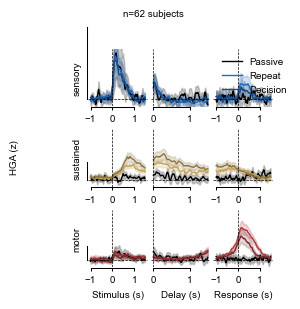

In [5]:
from matplotlib.colors import to_hex, to_rgb

phases = ["stimulus", "delay", "response"]
descriptions = ["Passive", "Repeat", "Decision"]
ylim = (-0.1, 0.7)
n_rows, n_cols = len(CLUSTERS), len(phases)


def mix_hex(color, other, amount):
    a = np.asarray(to_rgb(color))
    b = np.asarray(to_rgb(other))
    return to_hex(a * (1.0 - amount) + b * amount)


def cluster_condition_palette(cluster_color, present):
    shades = {
        "Passive": "black",
        "Repeat": cluster_color,
        "Decision": mix_hex(cluster_color, "black", 0.28),
    }
    return [shades[d] for d in present]

resp_passive = pooled_df[
    (pooled_df["phase"] == "response")
    & (pooled_df["description"] == "Passive")
    & (pooled_df["task"] != "LexicalNoDelay")
]
print(
    "response Passive tasks:",
    sorted(resp_passive.task.unique()) if len(resp_passive) else [],
    "| subjects:",
    resp_passive.subject.nunique() if len(resp_passive) else 0,
)

# Outlier Passive-response electrodes (large peak / temporal variance).
DROP_CHANNELS = {
    "D0125_LTMS3-4",
    "D0125_LTMS2-3",
    "D0125_LTMS1-2",
    "D0129_LFAI2-3",
}
fig_df = pooled_df[~pooled_df["channel"].isin(DROP_CHANNELS)].copy()
delay_passive = fig_df[
    (fig_df["phase"] == "delay")
    & (fig_df["description"] == "Passive")
]
print(
    "dropped",
    sorted(DROP_CHANNELS),
    "| remaining sensory Passive response electrodes:",
    fig_df.loc[
        (fig_df.functional_cluster == "sensory")
        & (fig_df.phase == "response")
        & (fig_df.description == "Passive")
        & (fig_df.task == "PictureNaming"),
        "channel",
    ].nunique(),
)
print(
    "delay Passive tasks:",
    sorted(delay_passive.task.unique()) if len(delay_passive) else [],
    "| subjects:",
    delay_passive.subject.nunique() if len(delay_passive) else 0,
    "| electrodes:",
    delay_passive.channel.nunique() if len(delay_passive) else 0,
)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(2.2 * n_cols * cm + 1.0 * cm, 2.4 * n_rows * cm),
    sharey="row",
    squeeze=False,
)
plt.subplots_adjust(wspace=0.05, hspace=0.4, left=0.28)

for row, cluster in enumerate(CLUSTERS):
    cluster_df = fig_df[fig_df["functional_cluster"] == cluster]
    label = CLUSTER_LABELS.get(cluster, cluster)
    cluster_color = FUNCTION_COLORS[cluster]
    for col, phase in enumerate(phases):
        ax = axes[row, col]
        phase_df = cluster_df[cluster_df["phase"] == phase]
        if phase == "response":
            phase_df = phase_df[
                ~(
                    (phase_df["description"] == "Passive")
                    & (phase_df["task"] == "LexicalNoDelay")
                )
            ]
        # Sustain @ stimulus: Passive is LexicalNoDelay only (not PictureNaming).
        if cluster == "sustain" and phase == "stimulus":
            phase_df = phase_df[
                ~(
                    (phase_df["description"] == "Passive")
                    & (phase_df["task"] != "LexicalNoDelay")
                )
            ]
        # Delay: Repeat/Decision are LexicalDelay. Passive is PictureNaming
        # (LexicalDelay has no Passive; LexicalNoDelay has no delay).
        if phase == "delay":
            phase_df = phase_df[
                (
                    (phase_df["task"] == "LexicalDelay")
                    & (phase_df["description"].isin(["Repeat", "Decision"]))
                )
                | (
                    (phase_df["task"] == "PictureNaming")
                    & (phase_df["description"] == "Passive")
                )
            ]
            phase_df = phase_df.loc[phase_df["time"] >= 0].copy()
        present = [d for d in descriptions if (phase_df["description"] == d).any()]
        if phase_df.empty or not present:
            ax.text(
                0.5,
                0.5,
                "n/a",
                ha="center",
                va="center",
                fontsize=fontsize,
                transform=ax.transAxes,
                color="0.6",
            )
        else:
            legend = row == 0 and col == n_cols - 1
            sns.lineplot(
                data=phase_df,
                x="time",
                y="value",
                hue="description",
                hue_order=present,
                ax=ax,
                palette=cluster_condition_palette(cluster_color, present),
                legend=legend,
                lw=1,
                errorbar=("ci", 95),
            )
            if legend and ax.get_legend() is not None:
                ax.legend(title="", fontsize=fontsize, frameon=False)
            elif ax.get_legend() is not None:
                ax.get_legend().remove()

        ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5)
        ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5)
        ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=0.5, trim=True)
        ax.set_ylim(*ylim)
        if col != 0:
            ax.set_yticklabels([])
            ax.set_yticks([])
            ax.spines["left"].set_visible(False)
        ax.set_xlabel(
            f"{phase.capitalize()} (s)" if row == n_rows - 1 else "",
            fontsize=fontsize,
        )
        ax.set_ylabel(label if col == 0 else "", fontsize=fontsize)

fig.supylabel("HGA (z)", fontsize=fontsize, x=0.02)
fig.suptitle(
    f"n={fig_df.subject.nunique()} subjects",
    fontsize=fontsize,
    y=1.02,
)
out = save_svg(fig, IMG_DIR / "fig3_context_pooled_stim_resp")
print("Wrote", out)
plt.show()

## 1b. Paired difference waveforms

Same cluster × phase grid as above. Each electrode enters a contrast only if **both** conditions exist in the **same task** (trial-averaged traces subtracted, then averaged across electrodes).

- **Repeat − Passive** — PictureNaming (matches the Delay P75 pairing)
- **Decision − Repeat** — LexicalDelay

Positive means the first condition is larger. These are two within-task pairings, not a three-condition subtraction across tasks. LexicalNoDelay is not used.



Repeat − Passive
functional_cluster  sensory  sustain  motor
phase                                      
stimulus                 13       41     55
delay                    13       41     55
response                 13       41     55
  subjects: {'stimulus': 27, 'delay': 27, 'response': 27}

Decision − Repeat
functional_cluster  sensory  sustain  motor
phase                                      
stimulus                 23       50     79
delay                    23       50     79
response                 23       50     79
  subjects: {'stimulus': 38, 'delay': 38, 'response': 38}
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig3/fig3_context_paired_delta.svg


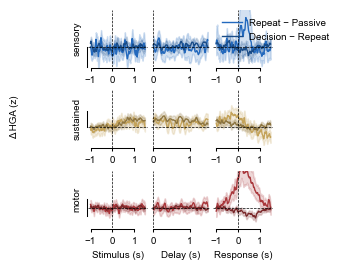

In [6]:
from matplotlib.colors import to_hex, to_rgb

phases = ["stimulus", "delay", "response"]
contrasts = ["Repeat − Passive", "Decision − Repeat"]
delta_ylim = (-0.25, 0.45)
keys = ["subject", "channel", "phase", "time"]


def mix_hex(color, other, amount):
    a = np.asarray(to_rgb(color))
    b = np.asarray(to_rgb(other))
    return to_hex(a * (1.0 - amount) + b * amount)


def contrast_palette(cluster_color, present):
    shades = {
        "Repeat − Passive": cluster_color,
        "Decision − Repeat": mix_hex(cluster_color, "black", 0.28),
    }
    return [shades[c] for c in present]


def electrode_paired_delta(df, *, task, cond_a, cond_b, contrast):
    """cond_a minus cond_b on electrodes that have both in this task."""
    sub = df.loc[df["task"] == task]
    left = (
        sub.loc[sub["description"] == cond_a, keys + ["functional_cluster", "value"]]
        .groupby(keys + ["functional_cluster"], as_index=False)["value"]
        .mean()
    )
    right = (
        sub.loc[sub["description"] == cond_b, keys + ["value"]]
        .groupby(keys, as_index=False)["value"]
        .mean()
    )
    merged = left.merge(right, on=keys, suffixes=("_a", "_b"))
    merged["value"] = merged["value_a"] - merged["value_b"]
    merged["contrast"] = contrast
    merged["task"] = task
    return merged[
        ["subject", "channel", "functional_cluster", "phase", "time", "task", "contrast", "value"]
    ]


delta_src = pooled_df[~pooled_df["channel"].isin(DROP_CHANNELS)].copy()
delta_parts = [
    electrode_paired_delta(
        delta_src,
        task="PictureNaming",
        cond_a="Repeat",
        cond_b="Passive",
        contrast="Repeat − Passive",
    ),
    electrode_paired_delta(
        delta_src,
        task="LexicalNoDelay",
        cond_a="Repeat",
        cond_b="Passive",
        contrast="Repeat − Passive",
    ),
    electrode_paired_delta(
        delta_src,
        task="LexicalDelay",
        cond_a="Decision",
        cond_b="Repeat",
        contrast="Decision − Repeat",
    ),
    electrode_paired_delta(
        delta_src,
        task="LexicalNoDelay",
        cond_a="Decision",
        cond_b="Repeat",
        contrast="Decision − Repeat",
    ),
]
delta_df = pd.concat(delta_parts, ignore_index=True)
delta_df = delta_df.loc[
    ~((delta_df["phase"] == "delay") & (delta_df["time"] < 0))
].copy()

for contrast in contrasts:
    for task, sub in delta_df.loc[delta_df["contrast"] == contrast].groupby("task"):
        print(f"\n{contrast} | {task}")
        if sub.empty:
            print("  (empty)")
            continue
        print(
            sub.groupby(["phase", "functional_cluster"])["channel"]
            .nunique()
            .unstack()
            .reindex(index=phases, columns=CLUSTERS)
            .fillna(0)
            .astype(int)
            .to_string()
        )
        print(
            "  subjects:",
            sub.groupby("phase")["subject"].nunique().reindex(phases).to_dict(),
        )

fig_delta = delta_df[
    delta_df["task"].isin(["PictureNaming", "LexicalDelay"])
].copy()

n_rows, n_cols = len(CLUSTERS), len(phases)
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(2.2 * n_cols * cm + 1.0 * cm, 2.4 * n_rows * cm),
    sharey="row",
    squeeze=False,
)
plt.subplots_adjust(wspace=0.05, hspace=0.4, left=0.28)

for row, cluster in enumerate(CLUSTERS):
    cluster_df = fig_delta[fig_delta["functional_cluster"] == cluster]
    label = CLUSTER_LABELS.get(cluster, cluster)
    cluster_color = FUNCTION_COLORS[cluster]
    for col, phase in enumerate(phases):
        ax = axes[row, col]
        phase_df = cluster_df[cluster_df["phase"] == phase]
        present = [c for c in contrasts if (phase_df["contrast"] == c).any()]
        if phase_df.empty or not present:
            ax.text(
                0.5,
                0.5,
                "n/a",
                ha="center",
                va="center",
                fontsize=fontsize,
                transform=ax.transAxes,
                color="0.6",
            )
        else:
            legend = row == 0 and col == n_cols - 1
            sns.lineplot(
                data=phase_df,
                x="time",
                y="value",
                hue="contrast",
                hue_order=present,
                ax=ax,
                palette=contrast_palette(cluster_color, present),
                legend=legend,
                lw=1,
                errorbar=("ci", 95),
            )
            if legend and ax.get_legend() is not None:
                ax.legend(title="", fontsize=fontsize, frameon=False)
            elif ax.get_legend() is not None:
                ax.get_legend().remove()

        ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5)
        ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5)
        ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=0.5, trim=True)
        ax.set_ylim(*delta_ylim)
        if col != 0:
            ax.set_yticklabels([])
            ax.set_yticks([])
            ax.spines["left"].set_visible(False)
        ax.set_xlabel(
            f"{phase.capitalize()} (s)" if row == n_rows - 1 else "",
            fontsize=fontsize,
        )
        ax.set_ylabel(label if col == 0 else "", fontsize=fontsize)

fig.supylabel("Δ HGA (z)", fontsize=fontsize, x=0.02)
out = save_svg(fig, IMG_DIR / "fig3_context_paired_delta")
print("Wrote", out)
plt.show()


## 1c. Difference waveforms by contrast

Same paired traces as 1b, rearranged: **one row per contrast × task**, three cluster colors in each panel.

- **Repeat − Passive**: PictureNaming, then LexicalNoDelay
- **Decision − Repeat**: LexicalDelay, then LexicalNoDelay

LexicalNoDelay Delay is empty (no delay phase). Still not Decision − Passive: that pairing exists in LexicalNoDelay but is a different contrast.


Rebuilt delta_df with task column from pooled_df.
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig3/fig3_context_paired_delta_by_contrast.svg


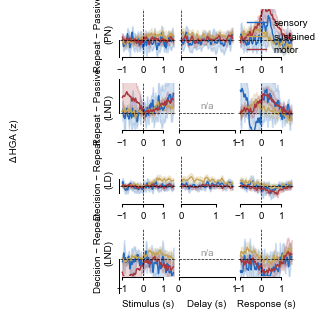

In [12]:
row_specs = [
    ("Repeat − Passive", "PictureNaming", "Repeat − Passive\n(PN)"),
    ("Repeat − Passive", "LexicalNoDelay", "Repeat − Passive\n(LND)"),
    ("Decision − Repeat", "LexicalDelay", "Decision − Repeat\n(LD)"),
    ("Decision − Repeat", "LexicalNoDelay", "Decision − Repeat\n(LND)"),
]
phases = ["stimulus", "delay", "response"]
delta_ylim = (-0.25, 0.45)

if "delta_df" not in globals() or "task" not in getattr(delta_df, "columns", []):
    if "pooled_df" not in globals():
        raise RuntimeError("Run the waveform load cell first.")
    keys = ["subject", "channel", "phase", "time"]

    def _rebuild_paired_delta(df, *, task, cond_a, cond_b, contrast):
        sub = df.loc[df["task"] == task]
        left = (
            sub.loc[sub["description"] == cond_a, keys + ["functional_cluster", "value"]]
            .groupby(keys + ["functional_cluster"], as_index=False)["value"]
            .mean()
        )
        right = (
            sub.loc[sub["description"] == cond_b, keys + ["value"]]
            .groupby(keys, as_index=False)["value"]
            .mean()
        )
        merged = left.merge(right, on=keys, suffixes=("_a", "_b"))
        merged["value"] = merged["value_a"] - merged["value_b"]
        merged["contrast"] = contrast
        merged["task"] = task
        return merged[
            ["subject", "channel", "functional_cluster", "phase", "time", "task", "contrast", "value"]
        ]

    delta_src = pooled_df[~pooled_df["channel"].isin(DROP_CHANNELS)].copy()
    delta_df = pd.concat(
        [
            _rebuild_paired_delta(
                delta_src,
                task="PictureNaming",
                cond_a="Repeat",
                cond_b="Passive",
                contrast="Repeat − Passive",
            ),
            _rebuild_paired_delta(
                delta_src,
                task="LexicalNoDelay",
                cond_a="Repeat",
                cond_b="Passive",
                contrast="Repeat − Passive",
            ),
            _rebuild_paired_delta(
                delta_src,
                task="LexicalDelay",
                cond_a="Decision",
                cond_b="Repeat",
                contrast="Decision − Repeat",
            ),
            _rebuild_paired_delta(
                delta_src,
                task="LexicalNoDelay",
                cond_a="Decision",
                cond_b="Repeat",
                contrast="Decision − Repeat",
            ),
        ],
        ignore_index=True,
    )
    delta_df = delta_df.loc[
        ~((delta_df["phase"] == "delay") & (delta_df["time"] < 0))
    ].copy()
    print("Rebuilt delta_df with task column from pooled_df.")

n_rows, n_cols = len(row_specs), len(phases)
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(2.2 * n_cols * cm + 1.6 * cm, 2.2 * n_rows * cm),
    sharey="row",
    squeeze=False,
)
plt.subplots_adjust(wspace=0.05, hspace=0.55, left=0.36)

for row, (contrast, task, ylabel) in enumerate(row_specs):
    contrast_df = delta_df[
        (delta_df["contrast"] == contrast) & (delta_df["task"] == task)
    ]
    for col, phase in enumerate(phases):
        ax = axes[row, col]
        phase_df = contrast_df[contrast_df["phase"] == phase]
        present = [c for c in CLUSTERS if (phase_df["functional_cluster"] == c).any()]
        if phase_df.empty or not present:
            ax.text(
                0.5,
                0.5,
                "n/a",
                ha="center",
                va="center",
                fontsize=fontsize,
                transform=ax.transAxes,
                color="0.6",
            )
        else:
            legend = row == 0 and col == n_cols - 1
            sns.lineplot(
                data=phase_df,
                x="time",
                y="value",
                hue="functional_cluster",
                hue_order=present,
                ax=ax,
                palette=[FUNCTION_COLORS[c] for c in present],
                legend=legend,
                lw=1,
                errorbar=("ci", 95),
            )
            if legend and ax.get_legend() is not None:
                handles, labels = ax.get_legend_handles_labels()
                ax.legend(
                    handles,
                    [CLUSTER_LABELS.get(lab, lab) for lab in labels],
                    title="",
                    fontsize=fontsize,
                    frameon=False,
                )
            elif ax.get_legend() is not None:
                ax.get_legend().remove()

        ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5)
        ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5)
        ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=0.5, trim=True)
        ax.set_ylim(*delta_ylim)
        if col != 0:
            ax.set_yticklabels([])
            ax.set_yticks([])
            ax.spines["left"].set_visible(False)
        ax.set_xlabel(
            f"{phase.capitalize()} (s)" if row == n_rows - 1 else "",
            fontsize=fontsize,
        )
        ax.set_ylabel(ylabel if col == 0 else "", fontsize=fontsize)

fig.supylabel("Δ HGA (z)", fontsize=fontsize, x=0.02)
out = save_svg(fig, IMG_DIR / "fig3_context_paired_delta_by_contrast")
print("Wrote", out)
plt.show()


## 2. Spatial: Decision > Repeat (Delay)

LexicalDelay `DecisionVsRepeatMean`, Delay window only, FDR-significant
Decision > Repeat. Render copied from `vizpub/fig2.ipynb` insula mesh.
No motor KDE contours.


In [7]:
from src.univariate.viz_cluster_direction import load_decision_vs_repeat_table

table, root = load_decision_vs_repeat_table(k=3)
print(f"results_root={root}")
print("phases in table:", sorted(table.phase.str.lower().unique()) if len(table) else [])

# Delay window only: after delay onset, before Go.
united = table.loc[
    (table["direction"] == "Decision")
    & (table["phase"].str.lower() == "delay")
].copy()
if "subject" in united.columns:
    united = united.loc[~united["subject"].isin(EXCLUDE_SUBJECTS)].copy()
if "channel" in united.columns:
    united = united.drop_duplicates(subset=["channel"], keep="first")
print(
    f"Delay Decision>Repeat channels: "
    f"{united.channel.nunique() if len(united) else 0}"
)
if len(united):
    print(
        united.groupby("functional_cluster")["channel"]
        .nunique()
        .reindex(CLUSTERS)
        .fillna(0)
        .astype(int)
        .to_string()
    )


results_root=/hpc/group/coganlab/nanlinshi/insula/results
phases in table: ['delay', 'go', 'response', 'stimulus']
Delay Decision>Repeat channels: 22
functional_cluster
sensory     3
sustain    16
motor       3


Using notebook 3d backend.
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot
plotting Delay Decision>Repeat channels: 22 | phases: ['delay']


2026-09-14 15:30:22.387 (   3.785s) [    7FAE406E5740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


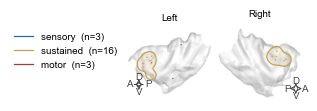

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig3/fig3_decision_gt_repeat_spatial_delay.svg
functional_cluster
sensory     3
sustain    16
motor       3


In [8]:
import os
import warnings

import pyvista as pv
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from mne.viz import Brain
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
pv.OFF_SCREEN = True
mne.viz.set_3d_backend("notebook")

recon_dir = "/cwork/ns458/ECoG_Recon/"
template = "cvs_avg35_inMNI152"
insula_patterns = (
    "G_insular_short",
    "G_Ins_lg_and_S_cent_ins",
    "S_circular_insula_ant",
    "S_circular_insula_inf",
    "S_circular_insula_sup",
)
POINT_SIZE = 10.0
KDE_BANDWIDTH_PX = 25.0
KDE_LEVEL_FRAC = 0.18
KDE_FILL_ALPHA = 0.12
KDE_MIN_POINTS = 2
CROP_PAD_PX = 24
INSULA_COLOR = (0.9, 0.9, 0.9)
INSULA_LABEL_ALPHA = 0.55

labels = mne.read_labels_from_annot(
    subject=template,
    parc="aparc.a2009s",
    surf_name="pial",
    hemi="both",
    subjects_dir=recon_dir,
)
lh_pial_coords, lh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/lh.pial")
rh_pial_coords, rh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def _insula_vertices(hemi: str) -> np.ndarray:
    verts = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            verts.extend(lab.vertices)
    if not verts:
        raise RuntimeError(f"No insula labels for {hemi}")
    return np.unique(verts)


def _faces_to_polydata(coords, faces) -> pv.PolyData:
    faces_pv = np.hstack(
        [np.full((len(faces), 1), 3, dtype=np.int64), np.asarray(faces, dtype=np.int64)]
    ).ravel()
    return pv.PolyData(np.asarray(coords, dtype=float), faces_pv)


def insula_mesh(hemi: str, pial: np.ndarray, faces: np.ndarray):
    verts = _insula_vertices(hemi)
    keep = np.all(np.isin(faces, verts), axis=1)
    mesh = _faces_to_polydata(pial, faces[keep])
    center = pial[verts].mean(axis=0)
    return mesh, center


lh_insula, lh_insula_center = insula_mesh("lh", lh_pial_coords, lh_faces)
rh_insula, rh_insula_center = insula_mesh("rh", rh_pial_coords, rh_faces)


def snap_to_pial(coords, tree, pial):
    _, idx = tree.query(coords)
    return pial[idx]


def add_cluster_spheres(brain, coords, clusters, tree, pial):
    coords = np.asarray(coords, dtype=float)
    if coords.size == 0:
        return np.zeros((0, 3), dtype=float)
    snapped = snap_to_pial(coords, tree, pial)
    for cluster in CLUSTERS:
        mask = np.asarray(clusters) == cluster
        if not mask.any():
            continue
        cloud = pv.PolyData(np.asarray(snapped[mask], dtype=float))
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=POINT_SIZE,
            color=FUNCTION_COLORS[cluster],
            lighting=False,
        )
    return snapped


def project_xy(plotter, points, image_shape):
    pts = np.asarray(points, dtype=float)
    if pts.size == 0:
        return np.zeros((0, 2), dtype=float)
    if hasattr(plotter, "project_points_to_pixels"):
        pix = np.asarray(plotter.project_points_to_pixels(pts), dtype=float)
        xy = np.asarray(pix[:, :2], dtype=float)
    else:
        import vtk

        renderer = plotter.renderer
        coordinate = vtk.vtkCoordinate()
        coordinate.SetCoordinateSystemToWorld()
        xy = np.zeros((len(pts), 2), dtype=float)
        for i, (x, y, z) in enumerate(pts):
            coordinate.SetValue(float(x), float(y), float(z))
            d = coordinate.GetComputedDisplayValue(renderer)
            xy[i] = (float(d[0]), float(d[1]))
    h = int(image_shape[0])
    xy[:, 1] = (h - 1) - xy[:, 1]
    return xy


def _keep_ring(ring, pts) -> bool:
    if len(pts) < KDE_MIN_POINTS:
        return False
    return int(MplPath(np.asarray(ring, dtype=float)).contains_points(pts).sum()) >= KDE_MIN_POINTS


def kde_contour_rings(xy, image_shape, *, bandwidth_px=KDE_BANDWIDTH_PX, level_frac=KDE_LEVEL_FRAC):
    pts = np.asarray(xy, dtype=float)
    if len(pts) < 3:
        return []
    h, w = int(image_shape[0]), int(image_shape[1])
    dens = np.zeros((h, w), dtype=float)
    xs = np.clip(np.round(pts[:, 0]).astype(int), 0, w - 1)
    ys = np.clip(np.round(pts[:, 1]).astype(int), 0, h - 1)
    for x, y in zip(xs, ys):
        dens[y, x] += 1.0
    dens = gaussian_filter(dens, sigma=float(bandwidth_px))
    peak = float(dens.max())
    if peak <= 0:
        return []
    level = peak * float(level_frac)
    try:
        from skimage.measure import find_contours

        contours = find_contours(dens, level=level)
        rings = []
        for cont in contours:
            if len(cont) < 8:
                continue
            ring = np.column_stack([cont[:, 1], cont[:, 0]])
            ring = np.vstack([ring, ring[0]])
            if _keep_ring(ring, pts):
                rings.append(ring)
        return rings
    except ImportError:
        fig_c, ax_c = plt.subplots()
        yy, xx = np.mgrid[0:h, 0:w]
        cs = ax_c.contour(xx, yy, dens, levels=[level])
        rings = []
        for segs in cs.allsegs:
            for seg in segs:
                if len(seg) < 8:
                    continue
                ring = np.vstack([seg, seg[0]])
                if _keep_ring(ring, pts):
                    rings.append(ring)
        plt.close(fig_c)
        return rings


def draw_rings(ax, rings, color):
    for ring in rings:
        ax.fill(ring[:, 0], ring[:, 1], color=color, alpha=KDE_FILL_ALPHA, linewidth=0, zorder=3)
        ax.plot(
            ring[:, 0],
            ring[:, 1],
            color=color,
            linewidth=0.9,
            solid_capstyle="round",
            solid_joinstyle="round",
            zorder=4,
        )


def draw_ap_dv(ax, *, anterior_is_left: bool, corner: str):
    if corner == "lower left":
        x0, y0, arm = 0.16, 0.18, 0.08
    else:
        x0, y0, arm = 0.91, 0.16, 0.07
    gap = 0.012
    if anterior_is_left:
        tips = {"A": (x0 - arm, y0), "P": (x0 + arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    else:
        tips = {"A": (x0 + arm, y0), "P": (x0 - arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    for label, (tx, ty) in tips.items():
        sx = x0 + gap * np.sign(tx - x0) if tx != x0 else x0
        sy = y0 + gap * np.sign(ty - y0) if ty != y0 else y0
        ax.annotate(
            "",
            xy=(tx, ty),
            xytext=(sx, sy),
            xycoords="axes fraction",
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="0.25", lw=0.7, mutation_scale=7),
            annotation_clip=False,
        )
        px = 0.03 * np.sign(tx - x0) if tx != x0 else 0.0
        py = 0.035 * np.sign(ty - y0) if ty != y0 else 0.0
        ax.text(
            tx + px,
            ty + py,
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=fontsize,
            color="0.25",
            clip_on=False,
        )


def crop_to_content(img, xy, pad=CROP_PAD_PX):
    rgb = np.asarray(img)
    mask = np.any(rgb < 250, axis=2)
    if not mask.any():
        return rgb, np.asarray(xy, dtype=float)
    ys, xs = np.nonzero(mask)
    y0 = max(0, int(ys.min()) - pad)
    y1 = min(rgb.shape[0], int(ys.max()) + 1 + pad)
    x0 = max(0, int(xs.min()) - pad)
    x1 = min(rgb.shape[1], int(xs.max()) + 1 + pad)
    xy_c = np.asarray(xy, dtype=float).copy()
    if xy_c.size:
        xy_c[:, 0] -= x0
        xy_c[:, 1] -= y0
    return rgb[y0:y1, x0:x1], xy_c


def render_hemi(hemi: str, coords, clusters):
    brain = Brain(
        template,
        subjects_dir=recon_dir,
        surf="pial",
        hemi=hemi,
        background="white",
        show=False,
        cortex=INSULA_COLOR,
        alpha=0.0,
        size=(800, 800),
    )
    plotter = brain._renderer.plotter
    mesh = lh_insula if hemi == "lh" else rh_insula
    plotter.add_mesh(
        mesh,
        color=INSULA_COLOR,
        opacity=INSULA_LABEL_ALPHA,
        lighting=True,
        smooth_shading=True,
    )
    tree = lh_tree if hemi == "lh" else rh_tree
    pial = lh_pial_coords if hemi == "lh" else rh_pial_coords
    snapped = add_cluster_spheres(brain, coords, clusters, tree, pial)
    center = lh_insula_center if hemi == "lh" else rh_insula_center
    az = 180 if hemi == "lh" else 0
    brain.show_view(azimuth=az, elevation=90, distance=180, focalpoint=center)
    for _ in range(3):
        plotter.render()
    img = np.asarray(brain.screenshot(mode="rgb"))
    xy = project_xy(plotter, snapped, img.shape[:2])
    brain.close()
    return img, xy


need = {"x", "y", "z", "functional_cluster", "channel"}
# Re-slice here so this cell does not reuse a leftover phase-union `united`.
united = table.loc[
    (table["direction"] == "Decision")
    & (table["phase"].str.lower() == "delay")
].copy()
if "subject" in united.columns:
    united = united.loc[~united["subject"].isin(EXCLUDE_SUBJECTS)].copy()
if "channel" in united.columns:
    united = united.drop_duplicates(subset=["channel"], keep="first")
print(
    "plotting Delay Decision>Repeat channels:",
    united.channel.nunique() if len(united) else 0,
    "| phases:",
    sorted(united.phase.str.lower().unique()) if len(united) else [],
)
missing = need - set(united.columns)
if missing:
    raise ValueError(f"Delay Decision table missing {sorted(missing)}")

spatial = united.loc[
    united["functional_cluster"].isin(CLUSTERS)
    & united[["x", "y", "z"]].notna().all(axis=1)
].copy()
cord = spatial[["x", "y", "z"]].to_numpy(float)
clust = spatial["functional_cluster"].to_numpy()
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lh_img, lh_xy = render_hemi("lh", cord[mask_lh], clust[mask_lh])
    rh_img, rh_xy = render_hemi("rh", cord[mask_rh], clust[mask_rh])

lh_img, lh_xy = crop_to_content(lh_img, lh_xy)
rh_img, rh_xy = crop_to_content(rh_img, rh_xy)
bw_px = KDE_BANDWIDTH_PX

fig, axes = plt.subplots(1, 2, figsize=(6.5 * cm, 3.0 * cm))
for ax, img, xy, clusters_hemi, title in (
    (axes[0], lh_img, lh_xy, clust[mask_lh], "Left"),
    (axes[1], rh_img, rh_xy, clust[mask_rh], "Right"),
):
    ax.imshow(img)
    ax.set_xlim(0, img.shape[1])
    ax.set_ylim(img.shape[0], 0)
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize)
    in_frame = (
        (xy[:, 0] >= 0)
        & (xy[:, 0] < img.shape[1])
        & (xy[:, 1] >= 0)
        & (xy[:, 1] < img.shape[0])
    )
    for cluster in CLUSTERS:
        if cluster == "motor":
            continue
        pts = xy[in_frame & (np.asarray(clusters_hemi) == cluster)]
        draw_rings(
            ax,
            kde_contour_rings(pts, img.shape[:2], bandwidth_px=bw_px),
            FUNCTION_COLORS[cluster],
        )
    if title == "Left":
        draw_ap_dv(ax, anterior_is_left=True, corner="lower left")
    else:
        draw_ap_dv(ax, anterior_is_left=False, corner="lower right")

n_by_cluster = spatial.groupby("functional_cluster")["channel"].nunique()
axes[0].legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=FUNCTION_COLORS[c],
            linewidth=0.9,
            label=f"{CLUSTER_LABELS[c]}  (n={int(n_by_cluster.get(c, 0))})",
        )
        for c in CLUSTERS
    ],
    frameon=False,
    fontsize=fontsize,
    loc="upper right",
    bbox_to_anchor=(-0.04, 1.0),
    borderaxespad=0.0,
)
fig.subplots_adjust(wspace=0.02, left=0.28, right=0.98, top=0.92, bottom=0.02)
out = save_svg(fig, IMG_DIR / "fig3_decision_gt_repeat_spatial_delay")
plt.show()
print("Wrote", out)
print(n_by_cluster.reindex(CLUSTERS).to_string())

## 3. Paired Delay P75 (2 × 3)

Rows = contrasts, columns = NMF clusters (sensory → sustain → motor).
Per-trial Delay summary is the 75th percentile.

- Top: PictureNaming Repeat vs Passive (Repeat | Passive). Highlight = uncorrected *p* < 0.05 and Repeat > Passive.
- Bottom: LexicalDelay Decision vs Repeat. Highlight = FDR and Decision > Repeat.

Highlighted points use the waveform palette: Passive black, Repeat = cluster color, Decision = darker cluster. Gray = not highlighted. Titles are cluster names; n is at the upper left of each panel.

Repeat>Passive Delay P75: 116 (unc p<0.05=16)
functional_cluster
sensory     3
sustain    10
motor       3
Decision>Repeat Delay P75: 154 (FDR=27)
functional_cluster
sensory     4
sustain    19
motor       4


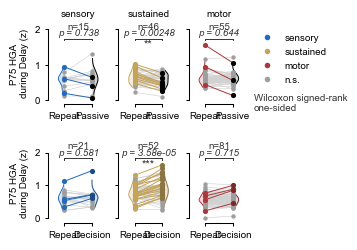

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig3/fig3_paired_delay_p75.svg
  Repeat>Passive sensory: n=15, sig=3, p=0.7378
  Repeat>Passive sustain: n=46, sig=10, p=0.002478
  Repeat>Passive motor: n=55, sig=3, p=0.6438
  Decision>Repeat sensory: n=21, sig=4, p=0.5809
  Decision>Repeat sustain: n=52, sig=19, p=3.584e-05
  Decision>Repeat motor: n=81, sig=4, p=0.7148


In [9]:
from matplotlib.colors import to_hex, to_rgb
from scipy.stats import gaussian_kde, wilcoxon

from src.paths import RESULTS_ROOT
from src.univariate.viz_cluster_direction import load_nmf_assignments
from src.univariate.viz_mean import (
    FALLBACK_MEAN_RESULTS,
    attach_metadata,
    filter_insula_electrodes,
    filter_qc,
    load_coord_metadata,
    load_mean_contrasts,
)


def _mix_hex(color, other, amount):
    a = np.asarray(to_rgb(color))
    b = np.asarray(to_rgb(other))
    return to_hex(a * (1.0 - amount) + b * amount)


def _condition_color(cluster, condition):
    base = FUNCTION_COLORS[cluster]
    if condition == "Passive":
        return "black"
    if condition == "Repeat":
        return base
    if condition == "Decision":
        return _mix_hex(base, "black", 0.28)
    raise ValueError(condition)


def _p_stars(p):
    if not np.isfinite(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


NS_COLOR = "0.62"
LINE_COLOR = "0.82"
X0, X1 = 0.0, 1.0
VIOLIN_W = 0.22
CLUSTER_DISPLAY = ["sensory", "sustain", "motor"]


def _load_paired(contrast, tasks, *, color_fdr):
    mean_df = load_mean_contrasts(
        RESULTS_ROOT,
        tasks=tasks,
        phase="Delay",
        contrast_desc=contrast,
    )
    coords = load_coord_metadata(FALLBACK_MEAN_RESULTS, tasks=tasks)
    paired = attach_metadata(mean_df, coords)
    paired = filter_qc(paired)
    paired = filter_insula_electrodes(paired)
    paired = paired.loc[
        (paired["contrast"] == contrast)
        & (paired["phase"].str.lower() == "delay")
    ].copy()
    if "subject" in paired.columns:
        paired = paired.loc[~paired["subject"].isin(EXCLUDE_SUBJECTS)].copy()
    assign = load_nmf_assignments(k=3)
    paired = paired.merge(
        assign[["channel", "functional_cluster"]],
        on="channel",
        how="inner",
    )
    paired = paired.drop_duplicates(subset=["channel"], keep="first")
    paired = paired.loc[paired[["mean_a", "mean_b"]].notna().all(axis=1)].copy()
    paired["significant"] = paired["significant"].astype(bool)
    if color_fdr:
        paired["sig_up"] = paired["significant"] & (paired["mean_a"] > paired["mean_b"])
    else:
        paired["sig_up"] = (paired["p_value"] < 0.05) & (paired["mean_a"] > paired["mean_b"])
    return paired.loc[paired["functional_cluster"].isin(CLUSTER_DISPLAY)].copy()


def _half_violin(ax, values, x, *, side, color):
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if len(v) < 3:
        return
    y = np.linspace(np.percentile(v, 2), np.percentile(v, 98), 200)
    dens = gaussian_kde(v)(y)
    dens = dens / dens.max() * VIOLIN_W
    xs = x - dens if side == "left" else x + dens
    ax.fill_betweenx(y, np.full_like(xs, x), xs, color=color, alpha=0.18, lw=0, zorder=0)
    ax.plot(xs, y, color=color, lw=0.7, zorder=1)


def _draw_cluster(
    ax, sub, cluster, *, xticklabels, ybar, span, ylim, left, right, show_title=True
):
    left_color = _condition_color(cluster, xticklabels[0])
    right_color = _condition_color(cluster, xticklabels[1])
    _half_violin(ax, sub[left], X0, side="left", color=left_color)
    _half_violin(ax, sub[right], X1, side="right", color=right_color)
    ns = sub.loc[~sub["sig_up"]]
    sig = sub.loc[sub["sig_up"]]
    for _, row in ns.iterrows():
        ax.plot(
            [X0, X1],
            [row[left], row[right]],
            color=LINE_COLOR,
            lw=0.45,
            zorder=1,
            solid_capstyle="round",
        )
    for _, row in sig.iterrows():
        ax.plot(
            [X0, X1],
            [row[left], row[right]],
            color=left_color,
            lw=0.7,
            zorder=2,
            solid_capstyle="round",
        )
    if len(ns):
        ax.scatter(
            np.full(len(ns), X0),
            ns[left],
            s=10,
            c=NS_COLOR,
            zorder=3,
            linewidths=0,
            clip_on=False,
        )
        ax.scatter(
            np.full(len(ns), X1),
            ns[right],
            s=10,
            c=NS_COLOR,
            zorder=3,
            linewidths=0,
            clip_on=False,
        )
    if len(sig):
        ax.scatter(
            np.full(len(sig), X0),
            sig[left],
            s=14,
            c=left_color,
            zorder=4,
            linewidths=0,
            clip_on=False,
        )
        ax.scatter(
            np.full(len(sig), X1),
            sig[right],
            s=14,
            c=right_color,
            zorder=4,
            linewidths=0,
            clip_on=False,
        )
    if len(sub) >= 8:
        _, p_c = wilcoxon(
            sub["mean_a"].to_numpy(float),
            sub["mean_b"].to_numpy(float),
            alternative="greater",
            zero_method="wilcox",
        )
        p_txt = f"p = {p_c:.3g}"
    else:
        p_c = np.nan
        p_txt = "n < 8"
    ax.plot([X0, X1], [ybar, ybar], color="0.2", lw=0.7, clip_on=False)
    ax.plot([X0, X0], [ybar - 0.03 * span, ybar], color="0.2", lw=0.7, clip_on=False)
    ax.plot([X1, X1], [ybar - 0.03 * span, ybar], color="0.2", lw=0.7, clip_on=False)
    ax.text(
        0.5,
        ybar + 0.02 * span,
        p_txt,
        ha="center",
        va="bottom",
        fontsize=fontsize,
        color="0.2",
        clip_on=False,
        fontstyle="italic",
        fontfamily="Arial",
    )
    ax.text(
        0.5,
        ybar + 0.14 * span,
        f"n={len(sub)}",
        ha="center",
        va="bottom",
        fontsize=fontsize,
        color="0.2",
        clip_on=False,
        fontfamily="Arial",
    )
    stars = _p_stars(p_c)
    if stars:
        ax.text(
            0.5,
            ybar - 0.015 * span,
            stars,
            ha="center",
            va="top",
            fontsize=fontsize + 1,
            color="0.2",
            clip_on=False,
            fontfamily="Arial",
        )
    ax.set_xlim(-0.55, 1.55)
    ax.set_ylim(*ylim)
    ax.set_xticks([X0, X1], xticklabels)
    if show_title:
        ax.set_title(CLUSTER_LABELS[cluster], fontsize=fontsize)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    return p_c


rvp = _load_paired("RepeatVsPassiveP75", ("PictureNaming",), color_fdr=False)
dvr = _load_paired("DecisionVsRepeatP75", ("LexicalDelay",), color_fdr=True)
print(
    f"Repeat>Passive Delay P75: {len(rvp)} "
    f"(unc p<0.05={int(rvp['sig_up'].sum())})"
)
print(
    rvp.loc[rvp["sig_up"]]
    .groupby("functional_cluster")["channel"]
    .nunique()
    .reindex(CLUSTER_DISPLAY)
    .fillna(0)
    .astype(int)
    .to_string()
)
print(
    f"Decision>Repeat Delay P75: {len(dvr)} "
    f"(FDR={int(dvr['sig_up'].sum())})"
)
print(
    dvr.loc[dvr["sig_up"]]
    .groupby("functional_cluster")["channel"]
    .nunique()
    .reindex(CLUSTER_DISPLAY)
    .fillna(0)
    .astype(int)
    .to_string()
)

rows = [
    (rvp, ["Repeat", "Passive"], "P75 HGA\nduring Delay (z)", "mean_a", "mean_b"),
    (dvr, ["Repeat", "Decision"], "P75 HGA\nduring Delay (z)", "mean_b", "mean_a"),
]
fig, axes = plt.subplots(2, 3, figsize=(6.5 * cm, 6.5 * cm), sharey="row")
fig.subplots_adjust(hspace=0.55, wspace=0.22)
cluster_stats = []
for row, (paired, ticks, ylabel, left, right) in enumerate(rows):
    ymin = float(np.nanmin(np.r_[paired["mean_a"], paired["mean_b"]]))
    ymax = float(np.nanmax(np.r_[paired["mean_a"], paired["mean_b"]]))
    span = ymax - ymin if ymax > ymin else 1.0
    ylim = (ymin - 0.08 * span, ymax + 0.38 * span)
    ybar = ymax + 0.12 * span
    for col, cluster in enumerate(CLUSTER_DISPLAY):
        ax = axes[row, col]
        sub = paired.loc[paired["functional_cluster"] == cluster].copy()
        p_c = _draw_cluster(
            ax,
            sub,
            cluster,
            xticklabels=ticks,
            ybar=ybar,
            span=span,
            ylim=ylim,
            left=left,
            right=right,
            show_title=row == 0,
        )
        cluster_stats.append((row, cluster, len(sub), int(sub["sig_up"].sum()), p_c))
    axes[row, 0].set_ylabel(ylabel, fontsize=fontsize)

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=FUNCTION_COLORS[c],
        markeredgecolor="none",
        markersize=4,
        label=CLUSTER_LABELS[c],
    )
    for c in CLUSTER_DISPLAY
] + [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=NS_COLOR,
        markeredgecolor="none",
        markersize=4,
        label="n.s.",
    )
]
leg = axes[0, -1].legend(
    handles=handles,
    frameon=False,
    fontsize=fontsize,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
)
fig.canvas.draw()
bbox = leg.get_window_extent(fig.canvas.get_renderer()).transformed(
    fig.transFigure.inverted()
)
fig.text(
    bbox.x0,
    bbox.y0 - 0.02,
    "Wilcoxon signed-rank\none-sided",
    ha="left",
    va="top",
    fontsize=fontsize,
    color="0.2",
    fontfamily="Arial",
    linespacing=1.25,
)

out = save_svg(fig, IMG_DIR / "fig3_paired_delay_p75")
plt.show()
print("Wrote", out)
for row, cluster, n, n_sig_c, p_c in cluster_stats:
    name = "Repeat>Passive" if row == 0 else "Decision>Repeat"
    p_str = f"{p_c:.4g}" if np.isfinite(p_c) else "NA"
    print(f"  {name} {cluster}: n={n}, sig={n_sig_c}, p={p_str}")